# Regresión Lineal para la Predicción del Volumen de GNV en Boyacá

**Curso:** Machine Learning 
**Autores:** María Isabel Hernández Bello  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

## 1. Carga y descripción de los datos

In [2]:
df = pd.read_csv(
    r"C:\Users\isabe\Documents\trabajos uni\Análisis_de_las_ventas_de_gas_natural_comprimido_vehicular_-_Departamento_de_Boyacá_20260917.csv"
)

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (5316, 15)


,FECHA VENTA,ANIO VENTA,MES VENTA,DIA VENTA,CODIGO MUNICIPIO_DANE,DEPARTAMENTO INSTALACION,MUNICIPIO INSTALACION,LATITUD,LONGITUD,TIPO AGENTE,TIPO DE COMBUSTIBLE,EDS ACTIVAS,NUMERO DE VENTAS,VEHICULOS ATENDIDOS,CANTIDAD VOLUMEN SUMINISTRADO
0,2023 Sep 08 12:00:00 AM,"2,023",9,8,"15,152",BOYACA,DUITAMA,"58,906,025,887","-730,670,928,955",ESTACION DE SERVICIO DE GNCV,GNV,2,229.0,176,"2,727.89"
1,2023 Sep 13 12:00:00 AM,"2,023",9,13,"15,157",BOYACA,SOGAMOSO,"56,466,722,488","-728,709,564,209",ESTACION DE SERVICIO DE GNCV,GNV,1,202.0,155,"1,749.66"
2,2023 Sep 12 12:00:00 AM,"2,023",9,12,"15,152",BOYACA,DUITAMA,"58,906,025,887","-730,670,928,955",ESTACION DE SERVICIO DE GNCV,GNV,2,188.0,154,"2,296.39"
3,2023 Sep 13 12:00:00 AM,"2,023",9,13,"15,152",BOYACA,DUITAMA,"58,906,025,887","-730,670,928,955",ESTACION DE SERVICIO DE GNCV,GNV,2,193.0,149,"2,508.82"
4,2023 Sep 11 12:00:00 AM,"2,023",9,11,"15,152",BOYACA,DUITAMA,"58,906,025,887","-730,670,928,955",ESTACION DE SERVICIO DE GNCV,GNV,2,206.0,158,"2,596.64"


## 2. Exploración inicial

In [3]:
print("Filas y columnas:", df.shape)

print("\nColumnas:")
print(df.columns.tolist())

print("\nInformación del dataset:")
df.info()

Filas y columnas: (5316, 15)

Columnas:
['FECHA VENTA', 'ANIO VENTA', 'MES VENTA', 'DIA VENTA', 'CODIGO MUNICIPIO_DANE', 'DEPARTAMENTO INSTALACION', 'MUNICIPIO INSTALACION', 'LATITUD', 'LONGITUD', 'TIPO AGENTE', 'TIPO DE COMBUSTIBLE', 'EDS ACTIVAS', 'NUMERO DE VENTAS', 'VEHICULOS ATENDIDOS', 'CANTIDAD VOLUMEN SUMINISTRADO']

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 5316 entries, 0 to 5315
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   FECHA VENTA                    5316 non-null   str    
 1   ANIO VENTA                     5316 non-null   str    
 2   MES VENTA                      5316 non-null   int64  
 3   DIA VENTA                      5316 non-null   int64  
 4   CODIGO MUNICIPIO_DANE          5316 non-null   str    
 5   DEPARTAMENTO INSTALACION       5316 non-null   str    
 6   MUNICIPIO INSTALACION          5316 non-null   str    
 7   LATITUD

## 3. Limpieza y preparación de datos

In [4]:
df["CANTIDAD VOLUMEN SUMINISTRADO"] = (
    df["CANTIDAD VOLUMEN SUMINISTRADO"]
    .str.replace(",", "", regex=False)
    .astype(float)
)

print("Tipo de dato:")
print(df["CANTIDAD VOLUMEN SUMINISTRADO"].dtype)

print("\nValores nulos:")
print(df.isnull().sum().sum())

Tipo de dato:
float64

Valores nulos:
0


## 4. Análisis exploratorio de datos (EDA)
### 4.1 Estadísticos descriptivos

In [5]:
df.describe()

,MES VENTA,DIA VENTA,EDS ACTIVAS,NUMERO DE VENTAS,VEHICULOS ATENDIDOS,CANTIDAD VOLUMEN SUMINISTRADO
count,5316.000000,5316.000000,5316.000000,5316.000000,5316.000000,5316.000000
mean,6.286117,15.692438,1.905192,339.749747,232.609481,3409.550129
std,3.317555,8.791235,0.732040,183.005167,109.107324,1817.640315
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.159000
25%,3.000000,8.000000,1.000000,221.000000,163.000000,2145.197500
50%,6.000000,16.000000,2.000000,296.500000,212.000000,3022.945000
75%,9.000000,23.000000,2.000000,446.000000,303.000000,4620.792500
max,12.000000,31.000000,4.000000,909.000000,601.000000,14402.170000


### 4.2 Distribución del volumen suministrado

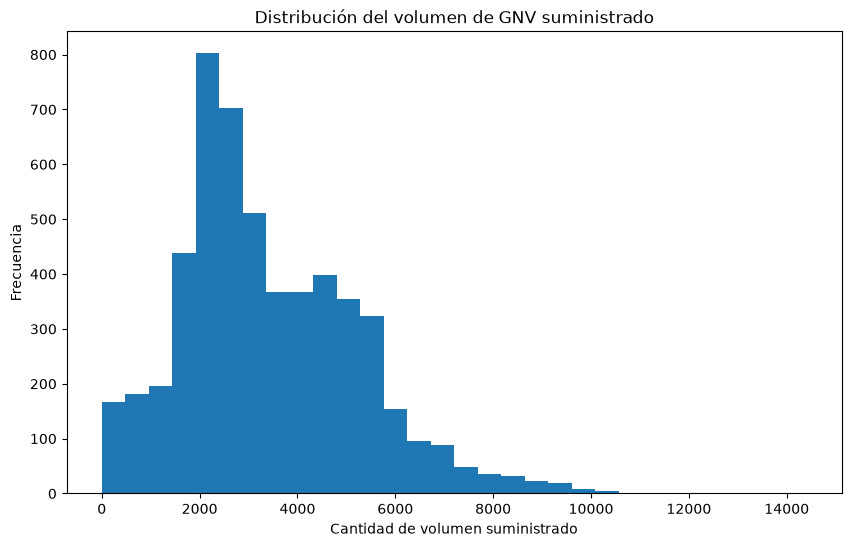

In [6]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["CANTIDAD VOLUMEN SUMINISTRADO"],
    bins=30
)

plt.title("Distribución del volumen de GNV suministrado")
plt.xlabel("Cantidad de volumen suministrado")
plt.ylabel("Frecuencia")

plt.show()

### 4.3 Correlación entre variables numéricas

In [7]:
variables_correlacion = [
    "NUMERO DE VENTAS",
    "VEHICULOS ATENDIDOS",
    "EDS ACTIVAS",
    "MES VENTA",
    "DIA VENTA",
    "CANTIDAD VOLUMEN SUMINISTRADO"
]

correlacion = df[variables_correlacion].corr()

correlacion

,NUMERO DE VENTAS,VEHICULOS ATENDIDOS,EDS ACTIVAS,MES VENTA,DIA VENTA,CANTIDAD VOLUMEN SUMINISTRADO
NUMERO DE VENTAS,1.000000,0.973959,0.406919,0.103910,-0.004328,0.696370
VEHICULOS ATENDIDOS,0.973959,1.000000,0.449342,0.090041,-0.003457,0.716628
EDS ACTIVAS,0.406919,0.449342,1.000000,0.003502,-0.007192,0.445543
MES VENTA,0.103910,0.090041,0.003502,1.000000,-0.003195,0.119062
DIA VENTA,-0.004328,-0.003457,-0.007192,-0.003195,1.000000,0.002876
CANTIDAD VOLUMEN SUMINISTRADO,0.696370,0.716628,0.445543,0.119062,0.002876,1.000000


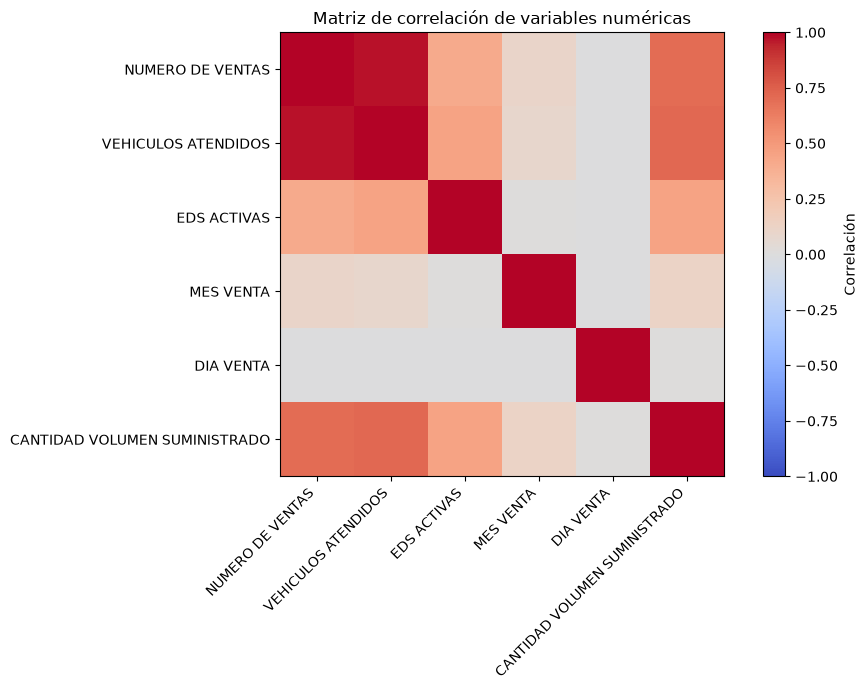

In [8]:
plt.figure(figsize=(10, 7))

plt.imshow(correlacion, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlación")

plt.xticks(
    range(len(correlacion.columns)),
    correlacion.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlacion.columns)),
    correlacion.columns
)

plt.title("Matriz de correlación de variables numéricas")

plt.tight_layout()
plt.show()

### 4.4 Identificación de valores potencialmente atípicos

In [10]:
Q1 = df["CANTIDAD VOLUMEN SUMINISTRADO"].quantile(0.25)
Q3 = df["CANTIDAD VOLUMEN SUMINISTRADO"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[
    (df["CANTIDAD VOLUMEN SUMINISTRADO"] < limite_inferior) |
    (df["CANTIDAD VOLUMEN SUMINISTRADO"] > limite_superior)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite superior:", limite_superior)
print("Posibles valores atípicos:", len(outliers))

Q1: 2145.1975
Q3: 4620.7925
IQR: 2475.5949999999993
Límite superior: 8334.184999999998
Posibles valores atípicos: 74


## 5. Modelado mediante Regresión Lineal

### 5.1 Definición de variables

In [11]:
X = df[
    [
        "NUMERO DE VENTAS",
        "EDS ACTIVAS",
        "MES VENTA"
    ]
]

y = df["CANTIDAD VOLUMEN SUMINISTRADO"]

### 5.2 División de los datos

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (4252, 3)
Prueba: (1064, 3)


### 5.3 Modelo 1

In [14]:
modelo = LinearRegression()

modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 674.9769
MSE: 1371138.7171
RMSE: 1170.9563
R²: 0.5538


### 5.4 Modelo 2

In [16]:
X2 = df[
    [
        "VEHICULOS ATENDIDOS",
        "EDS ACTIVAS",
        "MES VENTA"
    ]
]

y2 = df["CANTIDAD VOLUMEN SUMINISTRADO"]

print("Variables del Modelo 2:")
print(X2.columns.tolist())

Variables del Modelo 2:
['VEHICULOS ATENDIDOS', 'EDS ACTIVAS', 'MES VENTA']


In [17]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42
)

print("Entrenamiento:", X2_train.shape)
print("Prueba:", X2_test.shape)

Entrenamiento: (4252, 3)
Prueba: (1064, 3)


In [18]:
modelo2 = LinearRegression()

modelo2.fit(X2_train, y2_train)

print("Modelo 2 entrenado correctamente.")

Modelo 2 entrenado correctamente.


In [19]:
y2_pred = modelo2.predict(X2_test)

print("Primeras 10 predicciones del Modelo 2:")
print(y2_pred[:10])

Primeras 10 predicciones del Modelo 2:
[2169.76741279 2484.48278042 6331.30531464 4086.70585327 2811.62223098
 1366.16043198 3014.80333804 5322.23786491 3137.40591808 5446.59823648]


In [20]:
mae2 = mean_absolute_error(y2_test, y2_pred)
mse2 = mean_squared_error(y2_test, y2_pred)
rmse2 = mse2 ** 0.5
r2_2 = r2_score(y2_test, y2_pred)

print("RESULTADOS DEL MODELO 2")
print("-----------------------")
print(f"MAE:  {mae2:.4f}")
print(f"MSE:  {mse2:.4f}")
print(f"RMSE: {rmse2:.4f}")
print(f"R²:   {r2_2:.4f}")

RESULTADOS DEL MODELO 2
-----------------------
MAE:  694.8598
MSE:  1343747.8751
RMSE: 1159.2014
R²:   0.5627


### 5.5 Comparación de modelos

In [21]:
comparacion = pd.DataFrame({
    "Métrica": ["MAE", "MSE", "RMSE", "R²"],
    "Modelo 1": [mae, mse, rmse, r2],
    "Modelo 2": [mae2, mse2, rmse2, r2_2]
})

comparacion

,Métrica,Modelo 1,Modelo 2
0,MAE,6.749769e+02,6.948598e+02
1,MSE,1.371139e+06,1.343748e+06
2,RMSE,1.170956e+03,1.159201e+03
3,R²,5.537959e-01,5.627096e-01


## 6. Evaluación de supuestos del modelo

In [22]:
residuos2 = y2_test - y2_pred

print(residuos2.head())

230     -234.037413
2091     -38.232780
3862    1322.764685
439     -945.515853
3814    -226.362231
Name: CANTIDAD VOLUMEN SUMINISTRADO, dtype: float64


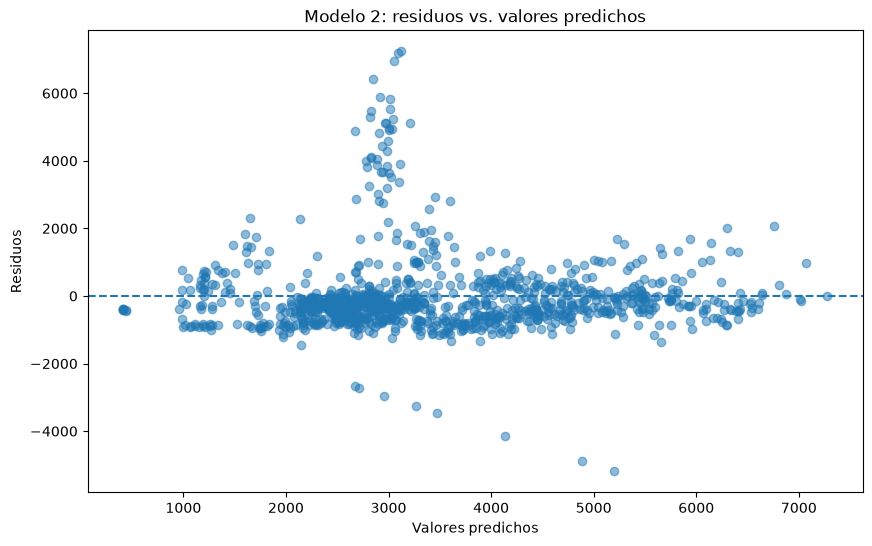

In [23]:
plt.figure(figsize=(10, 6))

plt.scatter(y2_pred, residuos2, alpha=0.5)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Modelo 2: residuos vs. valores predichos")

plt.show()

In [24]:
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

X2_test_const = sm.add_constant(X2_test)

resultado_bp2 = het_breuschpagan(
    residuos2,
    X2_test_const
)

print("Estadístico LM:", resultado_bp2[0])
print("p-valor LM:", resultado_bp2[1])
print("Estadístico F:", resultado_bp2[2])
print("p-valor F:", resultado_bp2[3])

Estadístico LM: 18.386231116182575
p-valor LM: 0.00036610603043075025
Estadístico F: 6.213066928769253
p-valor F: 0.0003491593474498896


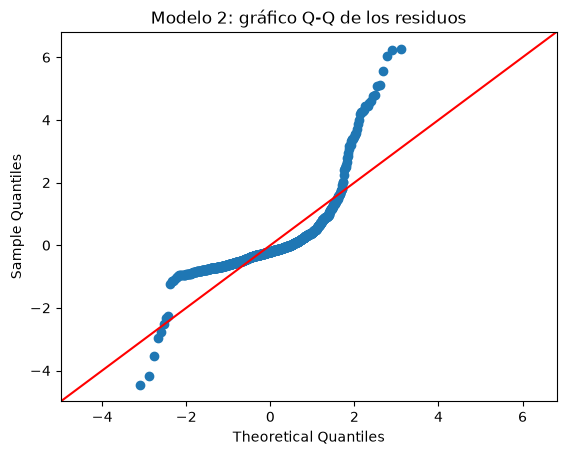

In [25]:
sm.qqplot(residuos2, line="45", fit=True)

plt.title("Modelo 2: gráfico Q-Q de los residuos")
plt.show()

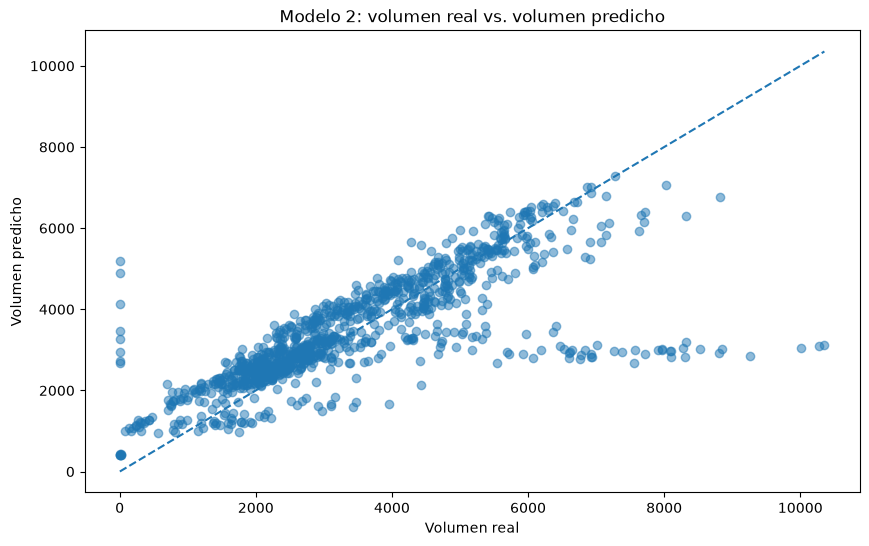

In [26]:
plt.figure(figsize=(10, 6))

plt.scatter(y2_test, y2_pred, alpha=0.5)

min_val = min(y2_test.min(), y2_pred.min())
max_val = max(y2_test.max(), y2_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Volumen real")
plt.ylabel("Volumen predicho")
plt.title("Modelo 2: volumen real vs. volumen predicho")

plt.show()

In [27]:
coeficientes2 = pd.DataFrame({
    "Variable": X2.columns,
    "Coeficiente": modelo2.coef_
})

print(coeficientes2)

print("\nIntercepto:", modelo2.intercept_)

              Variable  Coeficiente
0  VEHICULOS ATENDIDOS    10.666291
1          EDS ACTIVAS   395.174352
2            MES VENTA    33.756666

Intercepto: -29.648436558569756


In [28]:
comparacion = pd.DataFrame({
    "Métrica": ["MAE", "MSE", "RMSE", "R²"],
    "Modelo 1": [mae, mse, rmse, r2],
    "Modelo 2": [mae2, mse2, rmse2, r2_2]
})

comparacion

,Métrica,Modelo 1,Modelo 2
0,MAE,6.749769e+02,6.948598e+02
1,MSE,1.371139e+06,1.343748e+06
2,RMSE,1.170956e+03,1.159201e+03
3,R²,5.537959e-01,5.627096e-01


## 7. Conclusiones

El análisis permitió desarrollar un modelo de regresión lineal para estimar el volumen de GNV suministrado en estaciones de servicio de Boyacá. El Modelo 2, basado en vehículos atendidos, estaciones activas y mes de venta, obtuvo un R² de 0,5627 y un RMSE de 1.159,20.

Los resultados muestran que las variables seleccionadas permiten explicar una parte importante de la variabilidad del volumen suministrado. Sin embargo, el análisis de residuos evidenció limitaciones asociadas con heterocedasticidad y desviaciones respecto a la normalidad.

Entre las principales limitaciones se encuentran la presencia de valores potencialmente atípicos y la existencia de patrones que el modelo lineal no consigue representar completamente.

Como trabajo futuro se podría incorporar información adicional, explorar transformaciones de las variables, incluir variables categóricas como el municipio y evaluar otros modelos predictivos.